In [1]:
import torch
import transformers
print("Torch version:", torch.__version__)
print("CUDA disponível:", torch.cuda.is_available())

c:\Users\sthem\anaconda3\envs\swin_transformer\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch version: 2.6.0+cu118
CUDA disponível: True


In [28]:
import os
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import random

# Caminhos para os dados
DATASET_PATH = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\cell_images"
INFECTED_PATH = os.path.join(DATASET_PATH, "Parasitized")  # Células infectadas
UNINFECTED_PATH = os.path.join(DATASET_PATH, "Uninfected")  # Células saudáveis

# Transformações de imagem para Swin Transformer
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Tamanho esperado pelo Swin Transformer
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Criar dataset personalizado
class MalariaDataset(Dataset):
    def __init__(self, data_path, transform=None):
        self.data_path = data_path
        self.transform = transform
        self.images = []
        self.labels = []
        
        # Carregar imagens infectadas (1)
        for img_name in os.listdir(INFECTED_PATH):
            self.images.append(os.path.join(INFECTED_PATH, img_name))
            self.labels.append(1)
        
        # Carregar imagens não infectadas (0)
        for img_name in os.listdir(UNINFECTED_PATH):
            self.images.append(os.path.join(UNINFECTED_PATH, img_name))
            self.labels.append(0)

        # Embaralhar os dados
        temp = list(zip(self.images, self.labels))
        random.shuffle(temp)
        self.images, self.labels = zip(*temp)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert("RGB")
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
        
        return image, torch.tensor(label, dtype=torch.long)

# Criar instâncias do dataset
dataset = MalariaDataset(DATASET_PATH, transform=transform)

# Dividir em treino e teste (80% treino, 20% teste)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Tamanho do dataset: {len(dataset)}")
print(f"Imagens de treino: {len(train_dataset)}, Imagens de teste: {len(test_dataset)}")


Tamanho do dataset: 27558
Imagens de treino: 22046, Imagens de teste: 5512


In [29]:
from transformers import SwinForImageClassification

# Carregar modelo Swin Transformer pré-treinado
model_name = "microsoft/swin-tiny-patch4-window7-224"
model = SwinForImageClassification.from_pretrained(model_name, num_labels=2, ignore_mismatched_sizes=True)

# Usar GPU se disponível
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


SwinForImageClassification(
  (swin): SwinModel(
    (embeddings): SwinEmbeddings(
      (patch_embeddings): SwinPatchEmbeddings(
        (projection): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      )
      (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): SwinEncoder(
      (layers): ModuleList(
        (0): SwinStage(
          (blocks): ModuleList(
            (0): SwinLayer(
              (layernorm_before): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
              (attention): SwinAttention(
                (self): SwinSelfAttention(
                  (query): Linear(in_features=96, out_features=96, bias=True)
                  (key): Linear(in_features=96, out_features=96, bias=True)
                  (value): Linear(in_features=96, out_features=96, bias=True)
                  (dropout): Dropout(p=0.0, inplace=False)
                )
                (output): SwinSelfOutput(
        

In [30]:
import os
from PIL import Image

DATASET_PATH = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\cell_images"

# Listar arquivos que podem ser problemáticos
for folder in ["Parasitized", "Uninfected"]:
    folder_path = os.path.join(DATASET_PATH, folder)
    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        try:
            with Image.open(file_path) as img:
                img.verify()  # Verifica se a imagem é válida
        except Exception as e:
            print(f"Erro no arquivo: {file_path} - {str(e)}")


In [31]:
for folder in ["Parasitized", "Uninfected"]:
    folder_path = os.path.join(DATASET_PATH, folder)
    for file in os.listdir(folder_path):
        ext = os.path.splitext(file)[-1].lower()
        if ext not in [".png", ".jpg", ".jpeg"]:
            print(f"Arquivo inválido detectado: {file}")

#### Verificando o caminho

In [32]:
import os

DATASET_PATH = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\cell_images"

if os.path.exists(DATASET_PATH):
    print("✅ O caminho existe!")
else:
    print("❌ O caminho não foi encontrado. Verifique o nome e a estrutura do diretório.")

✅ O caminho existe!


In [33]:
sub_dirs = ["Parasitized", "Uninfected"]
for sub_dir in sub_dirs:
    sub_path = os.path.join(DATASET_PATH, sub_dir)
    if os.path.exists(sub_path):
        print(f"✅ O diretório {sub_dir} existe!")
    else:
        print(f"❌ O diretório {sub_dir} não foi encontrado dentro de {DATASET_PATH}.")

✅ O diretório Parasitized existe!
✅ O diretório Uninfected existe!


In [34]:
from PIL import Image

image_path = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\cell_images\Parasitized\C100P61ThinF_IMG_20150918_144104_cell_162.png"

try:
    img = Image.open(image_path)
    img.show()
    print("✅ A imagem foi carregada com sucesso!")
except Exception as e:
    print(f"❌ Erro ao carregar a imagem: {e}")


✅ A imagem foi carregada com sucesso!


In [35]:
folder_path = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\cell_images\Parasitized"

if os.path.exists(folder_path):
    print("📂 Arquivos na pasta:")
    print(os.listdir(folder_path))
else:
    print("❌ O diretório não foi encontrado.")


📂 Arquivos na pasta:
['C100P61ThinF_IMG_20150918_144104_cell_162.png', 'C100P61ThinF_IMG_20150918_144104_cell_163.png', 'C100P61ThinF_IMG_20150918_144104_cell_164.png', 'C100P61ThinF_IMG_20150918_144104_cell_165.png', 'C100P61ThinF_IMG_20150918_144104_cell_166.png', 'C100P61ThinF_IMG_20150918_144104_cell_167.png', 'C100P61ThinF_IMG_20150918_144104_cell_168.png', 'C100P61ThinF_IMG_20150918_144104_cell_169.png', 'C100P61ThinF_IMG_20150918_144104_cell_170.png', 'C100P61ThinF_IMG_20150918_144104_cell_171.png', 'C100P61ThinF_IMG_20150918_144348_cell_138.png', 'C100P61ThinF_IMG_20150918_144348_cell_139.png', 'C100P61ThinF_IMG_20150918_144348_cell_140.png', 'C100P61ThinF_IMG_20150918_144348_cell_141.png', 'C100P61ThinF_IMG_20150918_144348_cell_142.png', 'C100P61ThinF_IMG_20150918_144348_cell_143.png', 'C100P61ThinF_IMG_20150918_144348_cell_144.png', 'C100P61ThinF_IMG_20150918_144823_cell_157.png', 'C100P61ThinF_IMG_20150918_144823_cell_158.png', 'C100P61ThinF_IMG_20150918_144823_cell_159.png'

In [36]:
# Teste para verificar se o train_loader contém dados
data_iter = iter(train_loader)

try:
    images, labels = next(data_iter)
    print(f"✅ Train_loader carregado! Batch de imagens: {images.shape}, Labels: {labels}")
except StopIteration:
    print("❌ ERRO: train_loader está vazio!")


✅ Train_loader carregado! Batch de imagens: torch.Size([32, 3, 224, 224]), Labels: tensor([0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1,
        1, 0, 1, 1, 1, 0, 1, 0])


In [37]:
for images, labels in train_loader:
    print(f"✅ Batch carregado! Shape das imagens: {images.shape}, Labels: {labels}")
    break  # Testa apenas o primeiro batch


✅ Batch carregado! Shape das imagens: torch.Size([32, 3, 224, 224]), Labels: tensor([0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1,
        1, 1, 0, 0, 1, 0, 1, 1])


### Treinando o modelo

In [38]:
import torch.optim as optim
import torch.nn as nn

# Definir função de perda e otimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=5e-5)

# Função de treino
def train(model, train_loader, criterion, optimizer, device, epochs=5):
    model.train()
    
    for epoch in range(epochs):
        total_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images).logits  # Pegamos os logits do modelo
            
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        accuracy = correct / total
        print(f"Época {epoch+1}, Loss: {total_loss:.4f}, Acurácia: {accuracy:.4%}")

# Rodar o treinamento
train(model, train_loader, criterion, optimizer, device, epochs=5)


Época 1, Loss: 79.3148, Acurácia: 96.1807%
Época 2, Loss: 52.3939, Acurácia: 97.3419%
Época 3, Loss: 37.4948, Acurácia: 98.0223%
Época 4, Loss: 29.4460, Acurácia: 98.4759%
Época 5, Loss: 21.9879, Acurácia: 98.9114%


### testando no dataset de teste

In [39]:
def evaluate(model, test_loader, device):
    model.eval()
    
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).logits
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    
    accuracy = correct / total
    print(f"Acurácia no conjunto de teste: {accuracy:.4%}")

evaluate(model, test_loader, device)


Acurácia no conjunto de teste: 97.1880%


### testando com uma imagem individual

Classe prevista: Parasitized (Infectada)


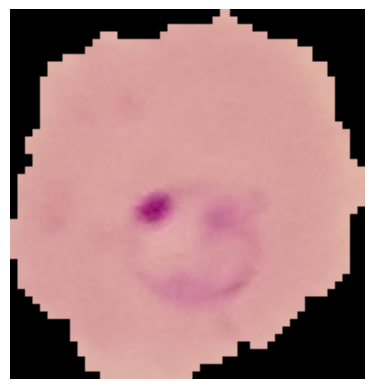

In [41]:
import matplotlib.pyplot as plt

def predict_image(image_path, model, transform, device):
    image = Image.open(image_path).convert("RGB")
    plt.imshow(image)
    plt.axis("off")
    
    image = transform(image).unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        output = model(image).logits
        _, predicted = torch.max(output, 1)
    
    label = "Parasitized (Infectada)" if predicted.item() == 1 else "Uninfected (Saudável)"
    print(f"Classe prevista: {label}")

# Teste com uma imagem do dataset
image_path = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\cell_images\Parasitized\C100P61ThinF_IMG_20150918_144104_cell_162.png"
predict_image(image_path, model, transform, device)
